In [1]:
#Preamble
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Problem 2

In [2]:
#Read file that my C++ script produced
data = pd.read_csv("Project1/OutputProblem2.txt", sep=' ', header=None)

#Isolate x and u
x = data[0]
u = data[1]

#Optional: print to verify
# print(data)

In [3]:
#Repeat how I would have done it in Python, as benchmark
xcheck = np.arange(0, 1, 0.01)
ucheck = 1-(1-np.exp(-10))*xcheck - np.exp(-10*xcheck)

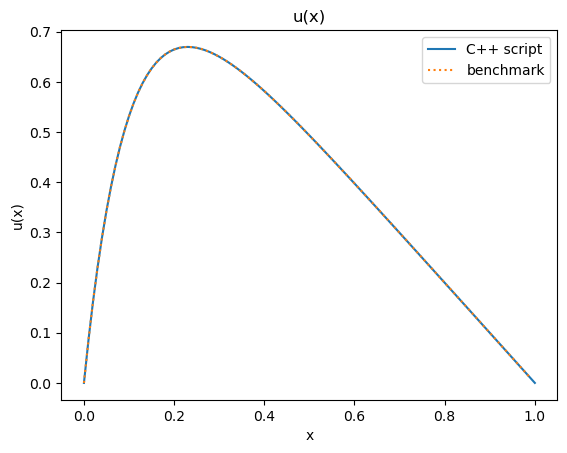

In [4]:
#Plot original data
plt.plot(x, u, label='C++ script')

#Plot benchmark
plt.plot(xcheck, ucheck, label='benchmark', linestyle=':')

#Customise
plt.legend()
plt.title("u(x)")
plt.xlabel('x')
plt.ylabel('u(x)')
plt.savefig('Project1/Fig2.png')

# Problem 7

In [5]:
#Read file that my C++ script produced
data = pd.read_csv("Project1/OutputProblem7_n10.txt", sep=' ', header=None)

#Isolate x and u
x = data[0]
v = data[1]

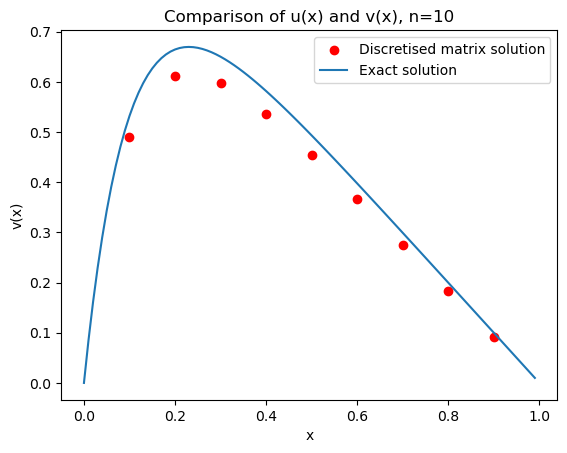

In [6]:
#Plot original data
plt.scatter(x, v, label='Discretised matrix solution', c='red')
plt.plot(xcheck, ucheck, label='Exact solution')

#Customise
plt.title("Comparison of u(x) and v(x), n=10")
plt.xlabel('x')
plt.ylabel('v(x)')
plt.legend()
plt.savefig('Project1/Fig7a.png')

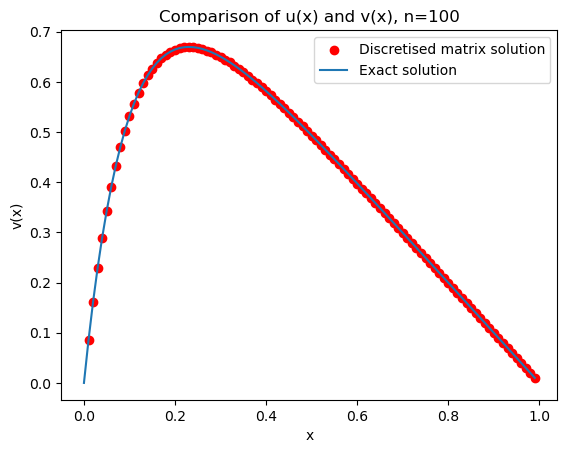

In [7]:
#Read file that my C++ script produced
data = pd.read_csv("Project1/OutputProblem7_n100.txt", sep=' ', header=None)

#Isolate x and u
x = data[0]
v = data[1]

#Plot original data
plt.scatter(x, v, label='Discretised matrix solution', c='red')
plt.plot(xcheck, ucheck, label='Exact solution')

#Customise
plt.title("Comparison of u(x) and v(x), n=100")
plt.xlabel('x')
plt.ylabel('v(x)')
plt.legend()

plt.savefig('Project1/Fig7b.png')

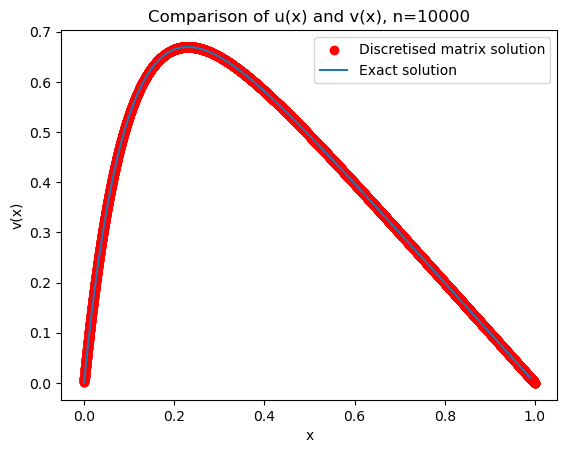

In [8]:
#Read file that my C++ script produced
data = pd.read_csv("Project1/OutputProblem7_n10000.txt", sep=' ', header=None)

#Isolate x and u
x = data[0]
v = data[1]

#Plot original data
plt.scatter(x, v, label='Discretised matrix solution', c='red')
plt.plot(xcheck, ucheck, label='Exact solution')

#Customise
plt.title("Comparison of u(x) and v(x), n=10000")
plt.xlabel('x')
plt.ylabel('v(x)')
plt.legend()

plt.savefig('Project1/Fig7c.png')

# Problem 8

a.)

In [9]:
def u_func(xvals):
    return 1-(1-np.exp(-10))*xvals - np.exp(-10*xvals)


def error_func(uvals, vvals):
    diff = abs(uvals-vvals)
    return np.log10(diff)

def relative_error_func(uvals, vvals):
    diff = abs((uvals-vvals)/uvals)
    return np.log10(diff)

def calculate_errors(data):
    x = data[0]
    v = data[1]

    #Calculate u for these x values
    u = u_func(x)

    #Error
    err = error_func(u, v)

    #Relative error
    rerr = relative_error_func(u, v)

    return x, err, rerr

In [10]:
#Data 10 points
x10, error10, relerror10 = calculate_errors(pd.read_csv("Project1/OutputProblem7_n10.txt", sep=' ', header=None))
#Data 100 points
x100, error100, relerror100 = calculate_errors(pd.read_csv("Project1/OutputProblem7_n100.txt", sep=' ', header=None))

#Data 1000 points
x1000, error1000, relerror1000 = calculate_errors(pd.read_csv("Project1/OutputProblem7_n1000.txt", sep=' ', header=None))

#Data 10000 points
x10000, error10000, relerror10000 = calculate_errors(pd.read_csv("Project1/OutputProblem7_n10000.txt", sep=' ', header=None))

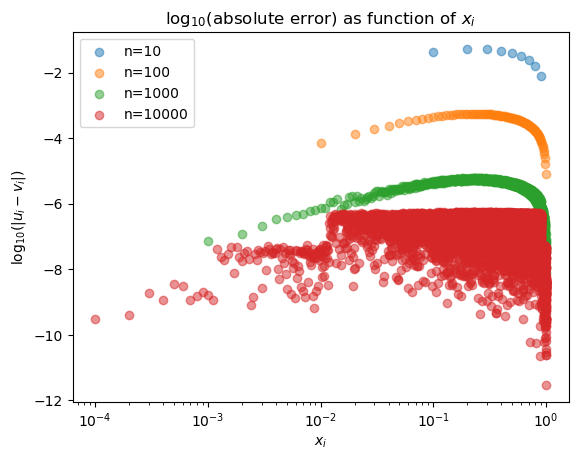

In [11]:
plt.scatter(x10, error10, label='n=10', alpha=0.5)
plt.scatter(x100, error100, label='n=100', alpha=0.5)
plt.scatter(x1000, error1000, label='n=1000', alpha=0.5)
plt.scatter(x10000, error10000, label='n=10000', alpha=0.5)

#Customise
plt.legend()
plt.title(r'log$_{10}$(absolute error) as function of $x_i$')
plt.xlabel(r'$x_i$')
plt.xscale('log')
plt.ylabel(r'log$_{10} (|u_i - v_i|)$')

plt.savefig('Project1/Fig8a.png')

b.)

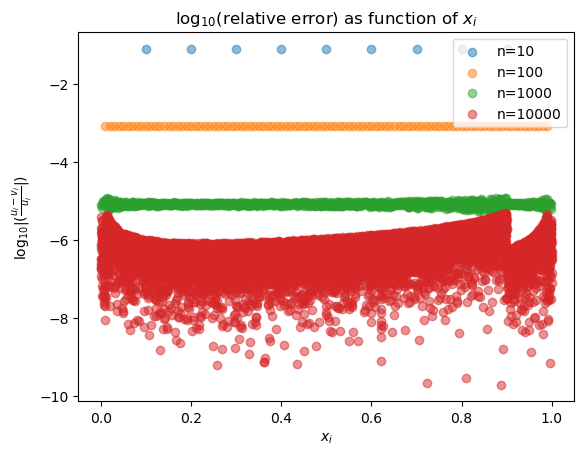

In [12]:
plt.scatter(x10, relerror10, label='n=10', alpha=0.5)
plt.scatter(x100, relerror100, label='n=100', alpha=0.5)
plt.scatter(x1000, relerror1000, label='n=1000', alpha=0.5)
plt.scatter(x10000, relerror10000, label='n=10000', alpha=0.5)

#Customise
plt.legend()
plt.xlabel(r'$x_i$')
plt.title(r'log$_{10}$(relative error) as function of $x_i$')
plt.ylabel(r'log$_{10} |(\frac{u_i - v_i}{u_i}|)$')

plt.savefig('Project1/Fig8b.png')

c.)

In [13]:
#Load in data until 10e7
x105, error105, relerror105 = calculate_errors(pd.read_csv("Project1/OutputProblem7_n105.txt", sep=' ', header=None))
x106, error106, relerror106 = calculate_errors(pd.read_csv("Project1/OutputProblem7_n106.txt", sep=' ', header=None))
x107, error107, relerror107 = calculate_errors(pd.read_csv("Project1/OutputProblem7_n107.txt", sep=' ', header=None))

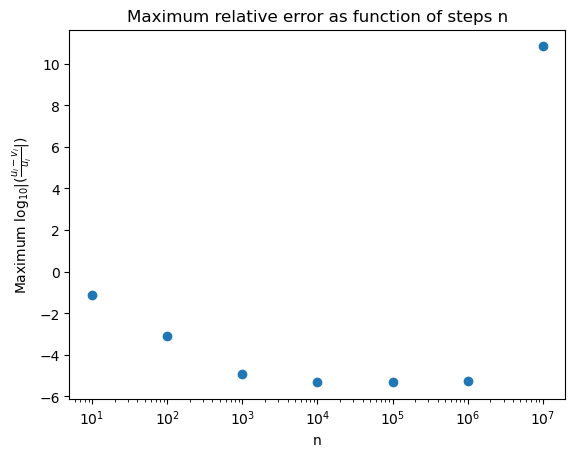

In [14]:
relerrors = [relerror10, relerror100, relerror1000, relerror10000, relerror105, relerror106, relerror107]
maxima = np.zeros(len(relerrors))
for i in range(len(relerrors)):
    maxima[i] = np.max(relerrors[i])

plt.scatter(np.logspace(1, len(relerrors), len(relerrors)), maxima)
plt.xscale('log')
plt.xlabel('n')
plt.title('Maximum relative error as function of steps n')
plt.ylabel(r'Maximum log$_{10} |(\frac{u_i - v_i}{u_i}|)$')

plt.savefig('Project1/Fig8c.png')

# Problem 9
Comparison of this v to u

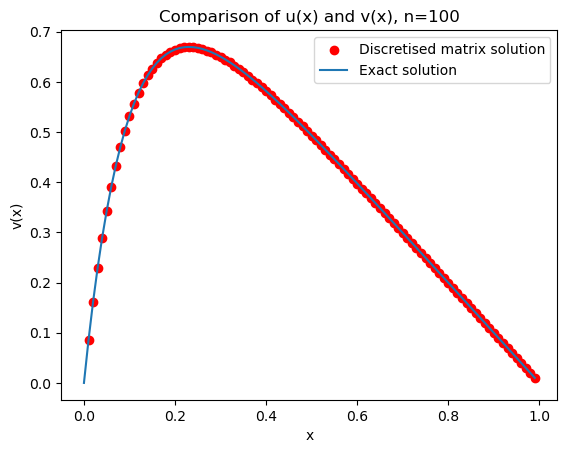

In [15]:
#Read file that my C++ script produced
data = pd.read_csv("Project1/OutputProblem9_n100.txt", sep=' ', header=None)

#Isolate x and u
x = data[0]
v = data[1]

#Plot original data
plt.scatter(x, v, label='Discretised matrix solution', c='red')
plt.plot(xcheck, ucheck, label='Exact solution')

#Customise
plt.title("Comparison of u(x) and v(x), n=100")
plt.xlabel('x')
plt.ylabel('v(x)')
plt.legend()
plt.savefig('Project1/Fig9.png')

# Problem 10

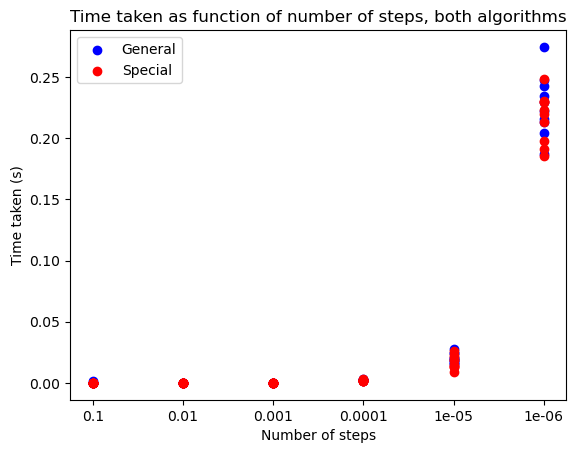

In [16]:
#Read file that my C++ script produced
gen = pd.read_csv("Project1/OutputProblem10_general.txt", sep=' ')
spec = pd.read_csv("Project1/OutputProblem10_special.txt", sep=' ')

#plot
for i in range(0, len(gen)):
    row = gen.iloc[i]
    if i==0:
        lab = 'General'
    else:
        lab = '_ignore'
    plt.scatter(row.index, row.values, c = 'blue', label = lab)

for i in range(0, len(spec)):
    row = spec.iloc[i]
    if i==0:
        lab = 'Special'
    else:
        lab = '_ignore'
    plt.scatter(row.index, row.values, c = 'red', label = lab)

plt.title('Time taken as function of number of steps, both algorithms')
plt.xlabel('Number of steps')
plt.ylabel('Time taken (s)')
plt.legend()
plt.savefig('Project1/Fig10a.png')

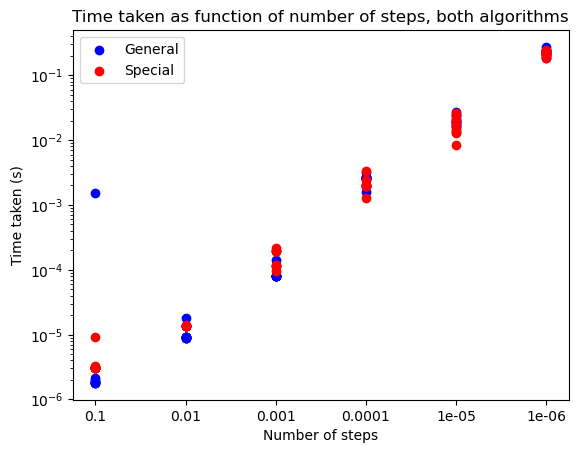

In [17]:
# With log scale
#plot
for i in range(0, len(gen)):
    row = gen.iloc[i]
    if i==0:
        lab = 'General'
    else:
        lab = '_ignore'
    plt.scatter(row.index, row.values, c = 'blue', label = lab)

for i in range(0, len(spec)):
    row = spec.iloc[i]
    if i==0:
        lab = 'Special'
    else:
        lab = '_ignore'
    plt.scatter(row.index, row.values, c = 'red', label = lab)

plt.title('Time taken as function of number of steps, both algorithms')
plt.xlabel('Number of steps')
plt.ylabel('Time taken (s)')
plt.legend()
plt.yscale('log')

plt.savefig('Project1/Fig10b.png')

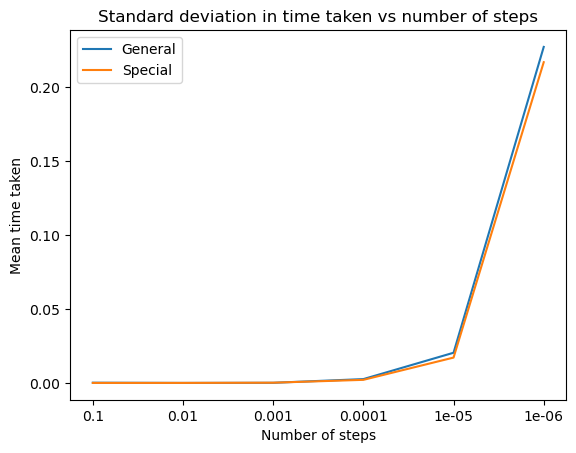

In [21]:
genm = gen.mean()
specm = spec.mean()

#Plot standard deviation
plt.plot(genm.index, genm.values, label = 'General')
plt.plot(specm.index, specm.values, label = 'Special')
plt.title('Standard deviation in time taken vs number of steps')
plt.xlabel('Number of steps')
plt.ylabel('Mean time taken')

plt.savefig('Project1/Fig10d.png')
plt.legend()

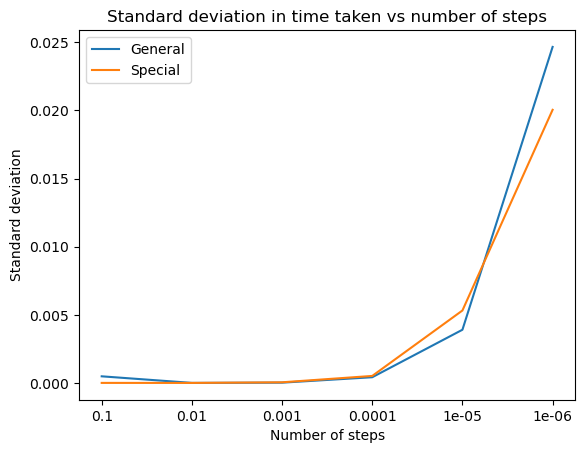

In [18]:
genvar = gen.std()
specvar = spec.std()

#Plot standard deviation
plt.plot(genvar.index, genvar.values, label = 'General')
plt.plot(specvar.index, specvar.values, label = 'Special')
plt.title('Standard deviation in time taken vs number of steps')
plt.xlabel('Number of steps')
plt.ylabel('Standard deviation')

plt.savefig('Project1/Fig10c.png')
plt.legend()